# Dimensions

../output_results/E_sent/main-2\lat_sc_100_2026-04-30_11-03-04_e-50_s-30_spatial.json
['spatial', 'lat-sc', '100']
../output_results/E_sent/main-2\lat_sc_25_2026-05-01_07-39-56_e-50_s-30_spatial.json
['spatial', 'lat-sc', '25']
../output_results/E_sent/main/lat_sc_2026-04-30_08-23-34_e-50_s-30_spatial.json
['spatial', 'lat-sc', '50']
[0 1 2] ['snn-spa-lat-sc-100', 'snn-spa-lat-sc-25', 'snn-spa-lat-sc-50'] [0.9774604358714766, 0.8374806841796771, 0.9268396653700645] [0.7529976019184652, 0.6853717026378897, 0.720863309352518]


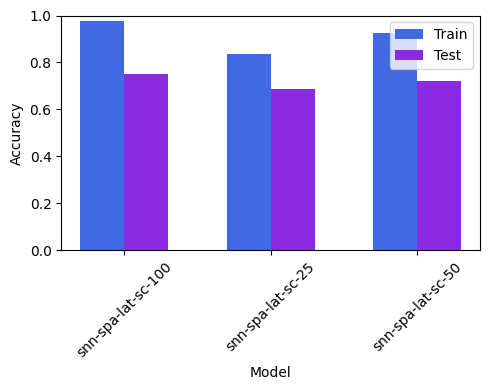

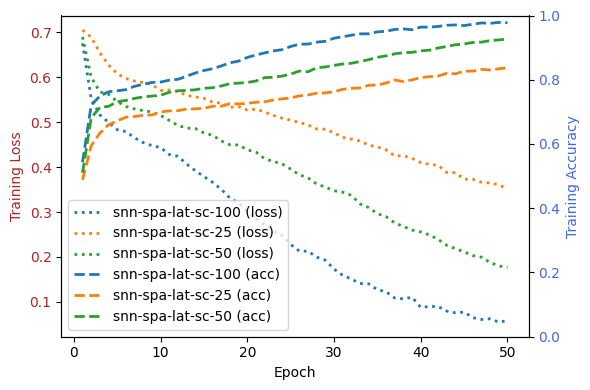

Writing accuracies to ..\output_results\E_sent\main-2\eval\snn_accuracies.tsv
Model	Train	Test	Training duration (min)
snn-spa-lat-sc-100	0.9775	0.7530	38.55
snn-spa-lat-sc-25	0.8375	0.6854	34.96
snn-spa-lat-sc-50	0.9268	0.7209	39.83


In [17]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
import numpy as np

from viz_util import colors, ModelNameConvention

files = sorted(glob('../output_results/E_sent/main-2/*.json'))
if not files:
    raise FileNotFoundError('No matching files found')
files.append('../output_results/E_sent/main/lat_sc_2026-04-30_08-23-34_e-50_s-30_spatial.json') #append 50d

file_labels = []
train_accuracies = []
test_accuracies = []
training_duration_min = []
epoch_losses_list = []
epoch_accuracies_list = []

for file_path in files:
    print(file_path)
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)

    file_name = Path(file_path).name
    label_parts = [data.get('training_config', {}).get('input_mode'), 'lat-sc', str(data.get('training_config', {}).get('embedding_dim'))]
    print(label_parts)
    label = '_'.join(label_parts)
    file_labels.append('snn-' + ModelNameConvention(label))
    train_accuracies.append(data['results']['epoch_train_accuracy'][-1])
    test_accuracies.append(data['results']['test_accuracy'])
    training_duration_min.append(data['training_config']['training_duration_s'] / 60.0)
    epoch_losses_list.append(data['results']['epoch_train_loss'])
    epoch_accuracies_list.append(data['results']['epoch_train_accuracy'])

# First plot: bar chart
x = np.arange(len(files))
print(x, file_labels, train_accuracies, test_accuracies)
width = 0.3

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x - width / 2, train_accuracies, width, label='Train', color=colors.train_accuracy)
ax.bar(x + width / 2, test_accuracies, width, label='Test', color=colors.test_accuracy)
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(file_labels, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Second plot: lines with dual y-axis (loss and accuracy over epochs)
fig, ax1 = plt.subplots(figsize=(6, 4))

# Plot loss on left y-axis
for loss_vals, label in zip(epoch_losses_list, file_labels):
    epochs = np.arange(1, len(loss_vals) + 1)
    ax1.plot(epochs, loss_vals, linestyle=':', label=f'{label} (loss)', linewidth=2)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=colors.loss)
ax1.tick_params(axis='y', labelcolor=colors.loss)

# Create right y-axis for accuracy
ax2 = ax1.twinx()
for acc_vals, label in zip(epoch_accuracies_list, file_labels):
    epochs = np.arange(1, len(acc_vals) + 1)
    ax2.plot(epochs, acc_vals, linestyle='--', label=f'{label} (acc)', linewidth=2)

ax2.set_ylabel('Training Accuracy', color=colors.train_accuracy)
ax2.tick_params(axis='y', labelcolor=colors.train_accuracy)
ax2.set_ylim(0, 1)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.tight_layout()
plt.show()

out_dir = Path(files[0]).parent / "eval"
out_dir.mkdir(exist_ok=True)
out_file_path = out_dir / 'snn_accuracies.tsv'
print(f'Writing accuracies to {out_file_path}')
with open(out_file_path, 'w', encoding='utf-8') as summary_file:
     summary_file.write('Model\tTrain accuracy\tTest accuracy\tTraining duration (min)\n')
     for label, train_accuracy, test_accuracy, duration_min in zip(file_labels, train_accuracies, test_accuracies, training_duration_min):
         summary_file.write(f'{label}\t{train_accuracy*100:.2f}\t{test_accuracy*100:.2f}\t{duration_min:.2f}\n')

print('Model\tTrain\tTest\tTraining duration (min)')
for label, train_accuracy, test_accuracy, duration_min in zip(file_labels, train_accuracies, test_accuracies, training_duration_min):
    print(f'{label}\t{train_accuracy:.4f}\t{test_accuracy:.4f}\t{duration_min:.2f}')

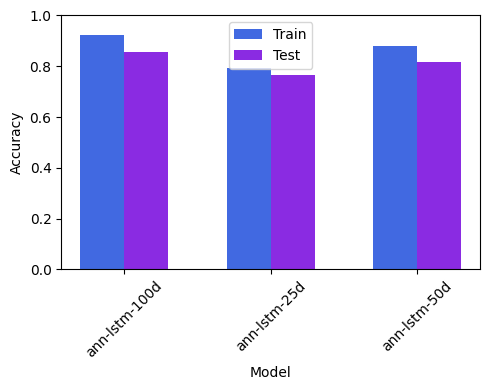

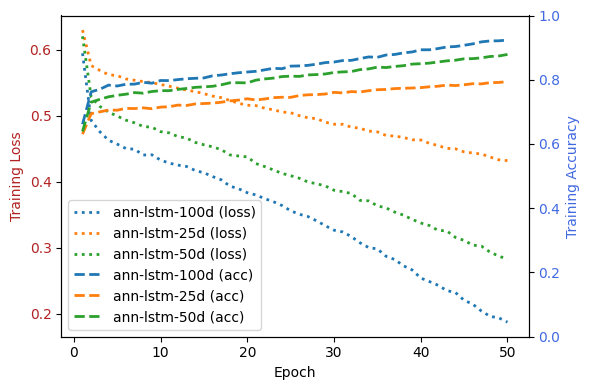

Writing accuracies to ..\output_results\E_sent\ANN\eval\ann_accuracies.tsv
Model	Train	Test	Training duration (min)
ann-lstm-100d	0.9235	0.8580	2.68
ann-lstm-25d	0.7942	0.7659	2.52
ann-lstm-50d	0.8788	0.8163	2.63


In [28]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
import numpy as np
from datetime import datetime

from viz_util import colors

files = sorted(glob('../output_results/E_sent/ANN/*.json'))
if not files:
    raise FileNotFoundError('No matching files found')

file_labels = []
train_accuracies = []
test_accuracies = []
training_duration_min = []
epoch_losses_list = []
epoch_accuracies_list = []

for file_path in files:
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)

    file_name = Path(file_path).name
    file_labels.append('-'.join(['ann-lstm', str(Path(file_path).stem).split('_')[1]]))
    train_accuracies.append(data['results']['epoch_train_accuracy'][-1])
    test_accuracies.append(data['results']['test_accuracy'])

    start = datetime.strptime(data['training_config']['training_start_date'], '%Y-%m-%d %H:%M:%S')
    end = datetime.strptime(data['training_config']['training_end_date'], '%Y-%m-%d %H:%M:%S')

    training_duration_min.append((end - start).total_seconds() / 60.0)
    epoch_losses_list.append(data['results']['epoch_train_loss'])
    epoch_accuracies_list.append(data['results']['epoch_train_accuracy'])

# First plot: bar chart
x = np.arange(len(files))
width = 0.3

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x - width / 2, train_accuracies, width, label='Train', color=colors.train_accuracy)
ax.bar(x + width / 2, test_accuracies, width, label='Test', color=colors.test_accuracy)
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(file_labels, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Second plot: lines with dual y-axis (loss and accuracy over epochs)
fig, ax1 = plt.subplots(figsize=(6, 4))

# Plot loss on left y-axis
for loss_vals, label in zip(epoch_losses_list, file_labels):
    epochs = np.arange(1, len(loss_vals) + 1)
    ax1.plot(epochs, loss_vals, linestyle=':', label=f'{label} (loss)', linewidth=2)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=colors.loss)
ax1.tick_params(axis='y', labelcolor=colors.loss)

# Create right y-axis for accuracy
ax2 = ax1.twinx()
for acc_vals, label in zip(epoch_accuracies_list, file_labels):
    epochs = np.arange(1, len(acc_vals) + 1)
    ax2.plot(epochs, acc_vals, linestyle='--', label=f'{label} (acc)', linewidth=2)

ax2.set_ylabel('Training Accuracy', color=colors.train_accuracy)
ax2.tick_params(axis='y', labelcolor=colors.train_accuracy)
ax2.set_ylim(0, 1)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.tight_layout()
plt.show()

out_dir = Path(files[0]).parent / "eval"
out_dir.mkdir(exist_ok=True)
out_file_path = out_dir / 'ann_accuracies.tsv'
print(f'Writing accuracies to {out_file_path}')
with open(out_file_path, 'w', encoding='utf-8') as summary_file:
     summary_file.write('Model\tTrain accuracy\tTest accuracy\tTraining duration (min)\n')
     for label, train_accuracy, test_accuracy, duration_min in zip(file_labels, train_accuracies, test_accuracies, training_duration_min):
         summary_file.write(f'{label}\t{train_accuracy*100:.2f}\t{test_accuracy*100:.2f}\t{duration_min:.2f}\n')

print('Model\tTrain\tTest\tTraining duration (min)')
for label, train_accuracy, test_accuracy, duration_min in zip(file_labels, train_accuracies, test_accuracies, training_duration_min):
    print(f'{label}\t{train_accuracy:.4f}\t{test_accuracy:.4f}\t{duration_min:.2f}')

In [11]:
def LSTM_FLOP_Estimate(batch_size, hidden_size, input_size, sequence_length=1):
    """
    Calculate FLOP count for LSTM computations per sample.
    
    Formula: FLOPs = [8BH² + 8BIH + 9BH] × T
    where:
        - B: batch size
        - H: hidden size (number of units)
        - I: input dimension
        - T: sequence length (timesteps)
    
    Args:
        batch_size: Batch size (B)
        hidden_size: Number of LSTM units (H)
        input_size: Input dimension (I)
        sequence_length: Sequence length in timesteps (T)
    
    Returns:
        Total FLOPs per batch
    """
    B = batch_size
    H = hidden_size
    I = input_size
    T = sequence_length
    
    # Calculate FLOPs: [8BH² + 8BIH + 9BH] × T
    flops_per_timestep = (8 * B * H * H) + (8 * B * I * H) + (9 * B * H)
    total_flops = flops_per_timestep * T
    
    return total_flops

def LSTM_Energy_Estimate(flops, mode='cpu'):
    """
    Estimate energy consumption for LSTM computations.
    
    Converts FLOPs to energy using marginal energy per operation costs:
    - CPU: 744 J/GFLOP
    - GPU: 890 J/GFLOP
    
    Formula: Energy (J) = FLOPs × (Cost_per_GFLOP / 10^9 FLOP/GFLOP)
    Result converted to picojoules (1 J = 10^12 pJ)
    
    Args:
        flops: Total FLOPs for the LSTM computations
        mode: 'cpu' or 'gpu' (default: 'cpu')
    
    Returns:
        Total energy in picojoules
    """
    # Energy cost per GFLOP
    costs_per_gflop = {
        'cpu': 744,    # J/GFLOP
        'gpu': 890     # J/GFLOP
    }
    
    if mode not in costs_per_gflop:
        raise ValueError(f"Invalid mode: {mode}. Use 'cpu' or 'gpu'.")
    
    cost_per_gflop = costs_per_gflop[mode]
    
    # Convert FLOPs to GFLOPs and calculate energy in Joules
    energy_joules = flops * (cost_per_gflop / 1e9)
    
    # Convert Joules to picojoules (1 J = 10^12 pJ)
    energy_pj = energy_joules * 1e12
    
    return energy_pj

def calculate_ann_total_energy(neurons_per_layer, emac_pj):
    """
    Calculate total energy for an ANN using MAC operations.
    
    Formula: E_ANN_total = Σ(N_{l-1} × N_l) × E_MAC
    where:
        - N_{l-1}: number of neurons in layer l-1
        - N_l: number of neurons in layer l
        - E_MAC: energy cost of a single MAC operation
    
    Args:
        neurons_per_layer: List of neuron counts for each layer [N_0, N_1, N_2, ..., N_L]
        emac_pj: Energy cost of a single MAC operation in picojoules
    
    Returns:
        Total energy in picojoules
    """
    total_energy = 0
    
    # Iterate through each layer (starting from layer 1)
    for l in range(1, len(neurons_per_layer)):
        n_prev = neurons_per_layer[l - 1]  # N_{l-1}
        n_curr = neurons_per_layer[l]      # N_l
        macs = n_prev * n_curr              # MAC operations for this layer
        energy_contribution = macs * emac_pj  # Energy for this layer
        total_energy += energy_contribution
        # print(f"Layer {l}: {n_prev} × {n_curr} = {macs} MACs → {energy_contribution:.2f} pJ")
    
    return total_energy

assert LSTM_FLOP_Estimate(1, 1, 1, 1) == 25 # Should be 25 FLOPs

for dim in [25, 50, 100]:
    lstm_flops = LSTM_FLOP_Estimate(batch_size=1, hidden_size=256+128, input_size=dim, sequence_length=1)
    # emac_energy_pj = 57.14  # Energy per MAC operation in picojoules from SNNLP paper
    emac_energy_pj = LSTM_Energy_Estimate(lstm_flops, mode='cpu')
    neurons_per_layer = [dim*10, 256, 128, 2]
    total_energy_mj = calculate_ann_total_energy(neurons_per_layer, emac_energy_pj) / 1_000_000_000
    print(f"Total ANN-{dim} cpu energy per sample: {total_energy_mj:.2f} mJ", lstm_flops, emac_energy_pj)

Total ANN-25 cpu energy per sample: 90947248.72 mJ 1259904 937368576000.0
Total ANN-50 cpu energy per sample: 160139620.12 mJ 1336704 994507776000.0
Total ANN-100 cpu energy per sample: 320465815.73 mJ 1490304 1108786176000.0


# NEURON MODEL

Evaluating ../output_results/E_sent/neuron_model\lat_sc_100_lif_2026-05-12_07-55-49_e-50_s-30_spatial.pt with input prefix sent_d100...
../output_results/E_sent/neuron_model\lat_sc_100_lif_2026-05-12_07-55-49_e-50_s-30_spatial.pt
Evaluation | samples=2085 | loss=1.2192 | acc=0.7530 | eval_time_ms=4077.18
Average AC operations per sample: 229904.55
Average energy per sample: 5892453.35 pJ (5892.4533 nJ)
Evaluating ../output_results/E_sent/neuron_model\lat_sc_100_qlif_2026-05-01_16-21-28_e-50_s-30_spatial.pt with input prefix sent_d100...
../output_results/E_sent/neuron_model\lat_sc_100_qlif_2026-05-01_16-21-28_e-50_s-30_spatial.pt
Evaluation | samples=2085 | loss=1.5181 | acc=0.7353 | eval_time_ms=4178.56
Average AC operations per sample: 411589.25
Average energy per sample: 10549032.07 pJ (10549.0321 nJ)
Evaluating ../output_results/E_sent/neuron_model\lat_sc_100_synaptic_2026-05-01_16-54-20_e-50_s-30_spatial.pt with input prefix sent_d100...
../output_results/E_sent/neuron_model\lat_s

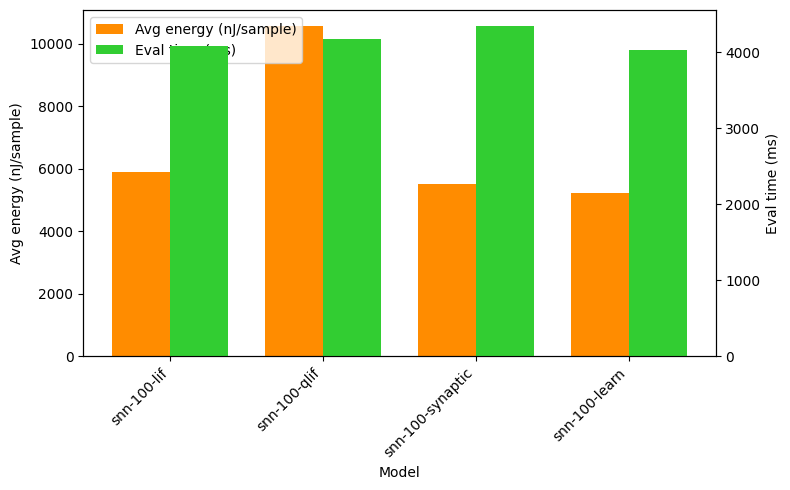

Writing results to ..\output_results\E_sent\neuron_model\eval\accuracies.tsv
Model	Train accuracy	Test accuracy	Energy (nJ/sample)	Eval time (s)	

snn-100-lif	97.93	75.30	5892.45	4.08
snn-100-qlif	93.44	73.53	10549.03	4.18
snn-100-synaptic	99.53	78.71	5514.32	4.34
snn-100-learn	99.36	76.55	5211.56	4.03


In [12]:
from E_sent_eval import evaluate_model
from glob import glob
from pathlib import Path
import json
from argparse import Namespace

import matplotlib.pyplot as plt
import numpy as np
from viz_util import colors

models = sorted(glob('../output_results/E_sent/neuron_model/*.pt'))
# models.append('../output_results/E_sent/main-2/lat_sc_100_2026-04-30_11-03-04_e-50_s-30_spatial.pt') # the LIF 100d model

labels = []
avg_energy_pj_per_sample = []
eval_time_ms = []
last_train_accuracy = []
eval_accuracy = []

for model_path in models:
    meta_path = Path(model_path).with_suffix('.json')
    with open(meta_path, 'r', encoding='utf-8') as meta_file:
        model_data = json.load(meta_file)

    meta = model_data.get('training_config', {})
    input_file_prefix = f"sent_d{meta.get('embedding_dim', 100)}"
    print(f"Evaluating {model_path} with input prefix {input_file_prefix}...")
    args = Namespace(**(meta | {
        "model_path": model_path,
        "input_file_prefix": input_file_prefix,
        "diagnose": False,
        # "diagnose": True,
        # "limit": 10,
        "limit": None,
        "split": "test",
        "estimate_energy": True,
        "energy_ac_cost_pj": 25.63,
        "output_json": None,
    }))
    # Try to cast each number-like argument to int if possible, since JSON doesn't distinguish.
    args = Namespace(**{k: (int(v) if isinstance(v, str) and v.isdigit() else v) for k, v in vars(args).items()})
    print(model_path)
    results = evaluate_model(args)
    labels.append('-'.join(['snn-100', (meta.get('output_file_prefix') or 'lif').split('_')[-1]]))
    avg_energy_pj_per_sample.append(results['avg_energy_pj_per_sample'] / 1000)  # convert pJ to nJ
    eval_time_ms.append(results.get('eval_time_ms', 0))
    last_train_accuracy.append(model_data['results']['epoch_train_accuracy'][-1])
    eval_accuracy.append(results['eval_accuracy'])

positions = np.arange(len(labels))
width = 0.38

fig, ax1 = plt.subplots(figsize=(max(8, len(labels) * 1.2), 5))
ax2 = ax1.twinx()

bars_energy = ax1.bar(positions - width/2, avg_energy_pj_per_sample, width, color=colors.energy, label='Avg energy (nJ/sample)')
bars_time = ax2.bar(positions + width/2, eval_time_ms, width, color=colors.time, label='Eval time (ms)')

ax1.set_xlabel('Model')
ax1.set_ylabel('Avg energy (nJ/sample)')
ax2.set_ylabel('Eval time (ms)')
ax1.set_xticks(positions)
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.tick_params(axis='y')
ax2.tick_params(axis='y')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()

out_dir = Path(models[0]).parent / 'eval'
out_dir.mkdir(exist_ok=True)
out_file_path = out_dir / 'accuracies.tsv'
print(f'Writing results to {out_file_path}')
with open(out_file_path, 'w', encoding='utf-8') as summary_file:
    summary_file.write('Model\tTrain accuracy\tTest accuracy\tEnergy (nJ/sample)\tEval time (s)\n')
    for label, energy_value, time_value, train_acc, test_acc in zip(labels, avg_energy_pj_per_sample, eval_time_ms, last_train_accuracy, eval_accuracy):
        summary_file.write(f'{label}\t{train_acc * 100:.2f}\t{test_acc * 100:.2f}\t{energy_value:.2f}\t{time_value/1000:.2f}\n')

print('Model\tTrain accuracy\tTest accuracy\tEnergy (nJ/sample)\tEval time (s)\t\n')
for label, energy_value, time_value, train_acc, test_acc in zip(labels, avg_energy_pj_per_sample, eval_time_ms, last_train_accuracy, eval_accuracy):
    print(f'{label}\t{train_acc * 100:.2f}\t{test_acc * 100:.2f}\t{energy_value:.2f}\t{time_value/1000:.2f}')